# Multi-Class Failure Classification

All previous notebooks answer a binary question: *will a failure occur in the next 24 hours?* This notebook asks a harder question: *which component will fail?*

The target has five classes: **none**, **comp1**, **comp2**, **comp3**, **comp4**. Predicting the specific component would give maintenance teams more actionable information — they could prepare the right spare parts before arriving at the machine.

The class distribution makes this substantially harder than binary classification:

| Class | Count | Share |
|-------|-------|-------|
| none  | 35,882 | 98.0% |
| comp2 |    250 |  0.7% |
| comp1 |    192 |  0.5% |
| comp4 |    155 |  0.4% |
| comp3 |    121 |  0.3% |

We compare two approaches:
1. **Direct multi-class** — one classifier outputs one of five labels
2. **Two-stage pipeline** — Stage 1 predicts *if* failure (binary), Stage 2 predicts *which component* among predicted positives

## 1. Setup

In [1]:
import warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      f1_score, recall_score, precision_score)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
FIG_DIR      = '../figures'

RF_PARAMS = dict(n_estimators=300, max_depth=20, max_features='sqrt',
                 min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1)

## 2. Build Multi-Class Target

In [2]:
df = pd.read_csv('../data/processed/merged_features.csv', parse_dates=['date'])

feature_cols = [c for c in df.columns
                if c not in ['machineID', 'date', 'failure_within_24h', 'failure_component']]

# Target: 0 = none, 1-4 = comp1-comp4
le = LabelEncoder()
y_multi = le.fit_transform(df['failure_component'])
class_names = le.classes_   # ['comp1', 'comp2', 'comp3', 'comp4', 'none']

X = df[feature_cols]

print('Class encoding:')
for i, c in enumerate(class_names):
    print(f'  {i} = {c}  ({(y_multi == i).sum()} samples)')
print(f'\nTotal: {len(y_multi):,} rows, {len(class_names)} classes')

Class encoding:
  0 = comp1  (192 samples)
  1 = comp2  (250 samples)
  2 = comp3  (121 samples)
  3 = comp4  (155 samples)
  4 = none  (35882 samples)

Total: 36,600 rows, 5 classes


## 3. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,} rows')
print(f'Test : {len(X_test):,} rows')
print('\nTest set class distribution:')
for i, c in enumerate(class_names):
    n = (y_test == i).sum()
    print(f'  {c}: {n}')

Train: 29,280 rows
Test : 7,320 rows

Test set class distribution:
  comp1: 39
  comp2: 50
  comp3: 24
  comp4: 31
  none: 7176


## 4. Direct Multi-Class Classification

We use `class_weight='balanced'` so the model does not simply predict *none* for everything. Balanced weighting scales each class's contribution to the loss by the inverse of its frequency.

In [4]:
# Random Forest with balanced class weights
rf_multi = RandomForestClassifier(**RF_PARAMS, class_weight='balanced')
rf_multi.fit(X_train, y_train)
pred_rf = rf_multi.predict(X_test)

print('Random Forest — Multi-Class Classification Report')
print('=' * 55)
print(classification_report(y_test, pred_rf,
                             target_names=class_names,
                             zero_division=0))

Random Forest — Multi-Class Classification Report
              precision    recall  f1-score   support

       comp1       0.92      0.92      0.92        39
       comp2       0.98      0.98      0.98        50
       comp3       0.92      0.96      0.94        24
       comp4       1.00      0.84      0.91        31
        none       1.00      1.00      1.00      7176

    accuracy                           1.00      7320
   macro avg       0.96      0.94      0.95      7320
weighted avg       1.00      1.00      1.00      7320



In [5]:
# XGBoost multi-class
n_classes = len(class_names)
xgb_multi = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.2,
    subsample=1.0, colsample_bytree=0.8,
    objective='multi:softmax', num_class=n_classes,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_multi.fit(X_train, y_train)
pred_xgb = xgb_multi.predict(X_test)

print('XGBoost — Multi-Class Classification Report')
print('=' * 55)
print(classification_report(y_test, pred_xgb,
                             target_names=class_names,
                             zero_division=0))

XGBoost — Multi-Class Classification Report
              precision    recall  f1-score   support

       comp1       1.00      1.00      1.00        39
       comp2       1.00      0.98      0.99        50
       comp3       0.92      0.96      0.94        24
       comp4       1.00      0.97      0.98        31
        none       1.00      1.00      1.00      7176

    accuracy                           1.00      7320
   macro avg       0.98      0.98      0.98      7320
weighted avg       1.00      1.00      1.00      7320



## 5. Confusion Matrices

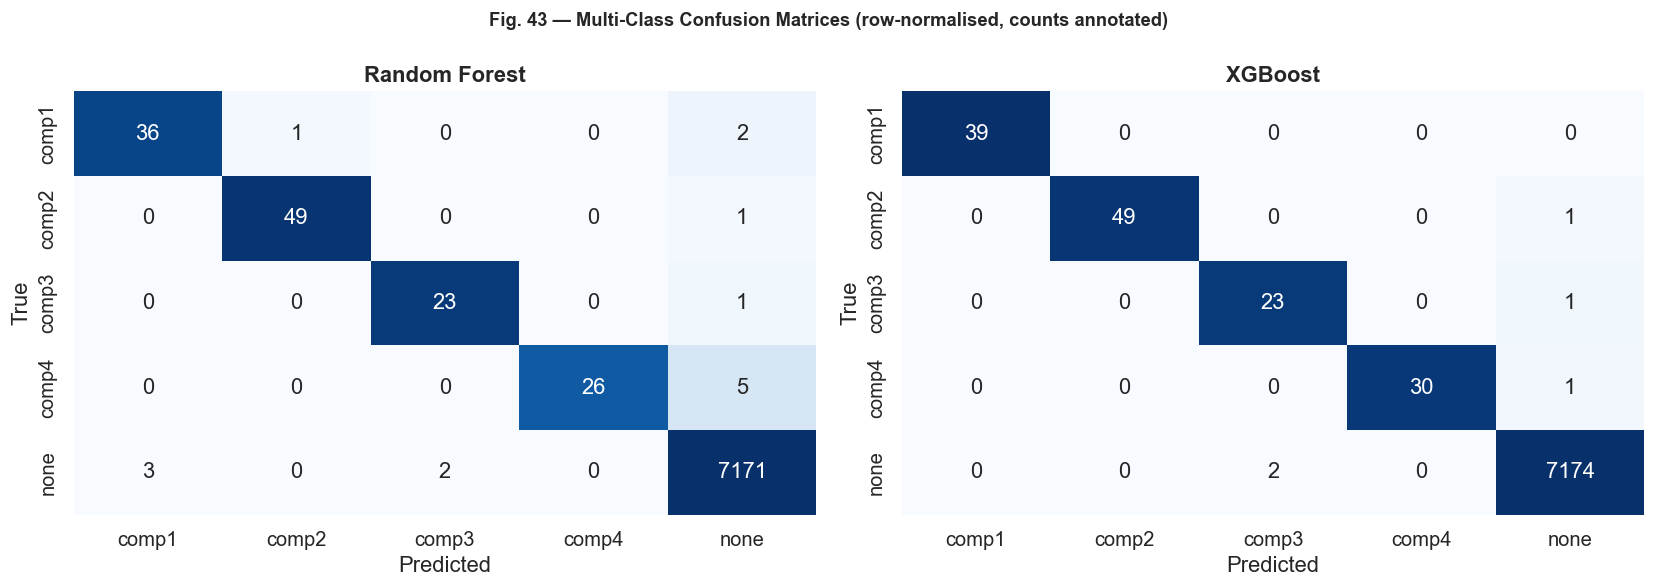

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in [
    (axes[0], pred_rf,  'Random Forest'),
    (axes[1], pred_xgb, 'XGBoost'),
]:
    cm = confusion_matrix(y_test, pred)
    # Row-normalise for readability (true label proportions)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}', fontweight='bold')

fig.suptitle('Fig. 43 — Multi-Class Confusion Matrices (row-normalised, counts annotated)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/multiclass_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Two-Stage Pipeline

Direct multi-class forces the model to solve detection and identification simultaneously. A two-stage approach separates the two problems:

- **Stage 1:** The binary RF model (already trained) flags which machine-days are failures.
- **Stage 2:** Among those predicted failures, a second classifier identifies the component.

Stage 2 is trained only on actual failure days, where class balance is much better (comp1: 192, comp2: 250, comp3: 121, comp4: 155). This makes the component identification problem much easier.

In [7]:
# Load the binary model
rf_binary = joblib.load('../models/random_forest_tuned.joblib')
y_binary  = df['failure_within_24h'].values

# Build Stage 2 training set: only actual failure days
# We use the same train/test split rows as above
# (X_train rows where the true label is not 'none')
none_idx = list(class_names).index('none')
failure_train_mask = (y_train != none_idx)
failure_test_mask  = (y_test  != none_idx)

X_tr2 = X_train[failure_train_mask]
y_tr2 = y_train[failure_train_mask]
X_te2 = X_test[failure_test_mask]
y_te2 = y_test[failure_test_mask]

print(f'Stage 2 training: {len(X_tr2)} failure days')
print(f'Stage 2 test    : {len(X_te2)} failure days')
print('Stage 2 class distribution (test):')
for i, c in enumerate(class_names):
    if c == 'none': continue
    print(f'  {c}: {(y_te2==i).sum()}')

Stage 2 training: 574 failure days
Stage 2 test    : 144 failure days
Stage 2 class distribution (test):
  comp1: 39
  comp2: 50
  comp3: 24
  comp4: 31


In [8]:
# Train Stage 2 classifier on failure-only data
rf_stage2 = RandomForestClassifier(**RF_PARAMS, class_weight='balanced')
rf_stage2.fit(X_tr2, y_tr2)

# Stage 2 standalone accuracy (among true failure days)
pred_stage2_true = rf_stage2.predict(X_te2)
print('Stage 2 component classifier — true failure days only:')
print(classification_report(y_te2, pred_stage2_true,
                             target_names=[c for c in class_names if c != 'none'],
                             labels=[i for i,c in enumerate(class_names) if c != 'none'],
                             zero_division=0))

Stage 2 component classifier — true failure days only:
              precision    recall  f1-score   support

       comp1       0.95      0.97      0.96        39
       comp2       0.98      1.00      0.99        50
       comp3       1.00      1.00      1.00        24
       comp4       1.00      0.94      0.97        31

    accuracy                           0.98       144
   macro avg       0.98      0.98      0.98       144
weighted avg       0.98      0.98      0.98       144



In [9]:
# Full two-stage pipeline on the whole test set
# Stage 1: binary detection
y_bin_test   = (y_test != none_idx).astype(int)
y_bin_true   = (y_test != none_idx).astype(int)  # same thing, for clarity
pred_binary  = rf_binary.predict(X_test)

# Stage 2: component ID on predicted positives from Stage 1
pred_twostage = np.full(len(X_test), none_idx, dtype=int)  # default: none
pos_mask = pred_binary == 1
if pos_mask.sum() > 0:
    pred_twostage[pos_mask] = rf_stage2.predict(X_test[pos_mask])

print('Two-Stage Pipeline — Full Test Set:')
print('=' * 55)
print(classification_report(y_test, pred_twostage,
                             target_names=class_names,
                             zero_division=0))

Two-Stage Pipeline — Full Test Set:
              precision    recall  f1-score   support

       comp1       0.93      0.97      0.95        39
       comp2       0.98      1.00      0.99        50
       comp3       0.96      1.00      0.98        24
       comp4       1.00      0.94      0.97        31
        none       1.00      1.00      1.00      7176

    accuracy                           1.00      7320
   macro avg       0.97      0.98      0.98      7320
weighted avg       1.00      1.00      1.00      7320



## 7. Summary Comparison

In [10]:
def macro_f1(y_true, y_pred, none_idx):
    """Macro F1 excluding the 'none' class."""
    labels = [i for i in range(len(class_names)) if i != none_idx]
    return round(f1_score(y_true, y_pred, labels=labels, average='macro',
                          zero_division=0), 4)

summary = pd.DataFrame([
    {
        'Approach': 'Direct multi-class (RF)',
        'Macro F1 (failure classes)': macro_f1(y_test, pred_rf, none_idx),
        'Weighted F1': round(f1_score(y_test, pred_rf, average='weighted',
                                      zero_division=0), 4),
    },
    {
        'Approach': 'Direct multi-class (XGBoost)',
        'Macro F1 (failure classes)': macro_f1(y_test, pred_xgb, none_idx),
        'Weighted F1': round(f1_score(y_test, pred_xgb, average='weighted',
                                      zero_division=0), 4),
    },
    {
        'Approach': 'Two-stage pipeline (RF)',
        'Macro F1 (failure classes)': macro_f1(y_test, pred_twostage, none_idx),
        'Weighted F1': round(f1_score(y_test, pred_twostage, average='weighted',
                                      zero_division=0), 4),
    },
]).set_index('Approach')

display(summary)

print()
print('Binary task (reference): F1 = 0.9724')
print('Multi-class macro F1 (failure classes):', summary['Macro F1 (failure classes)'].max())
print()
print('The gap between binary and multi-class F1 shows the added difficulty')
print('of identifying the specific component, not just detecting a failure.')

,Macro F1 (failure classes),Weighted F1
Approach,,
Direct multi-class (RF),0.9385,0.9979
Direct multi-class (XGBoost),0.9781,0.9993
Two-stage pipeline (RF),0.9716,0.9993



Binary task (reference): F1 = 0.9724
Multi-class macro F1 (failure classes): 0.9781

The gap between binary and multi-class F1 shows the added difficulty
of identifying the specific component, not just detecting a failure.


## 8. Per-Class Recall Bar Chart

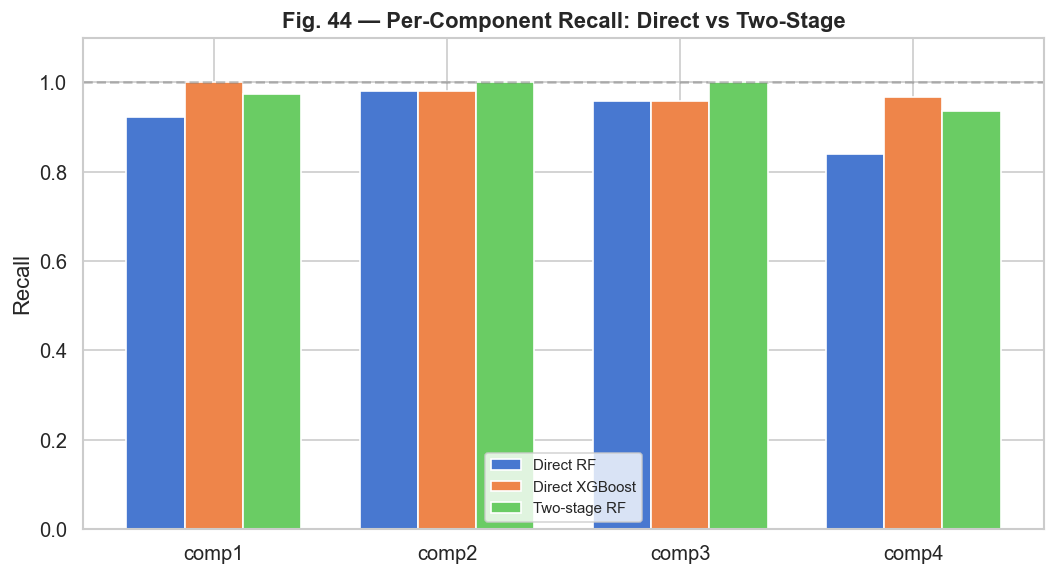

In [11]:
failure_classes = [c for c in class_names if c != 'none']
failure_labels  = [i for i,c in enumerate(class_names) if c != 'none']

recalls_rf  = recall_score(y_test, pred_rf,      labels=failure_labels,
                            average=None, zero_division=0)
recalls_xgb = recall_score(y_test, pred_xgb,     labels=failure_labels,
                            average=None, zero_division=0)
recalls_2st = recall_score(y_test, pred_twostage, labels=failure_labels,
                            average=None, zero_division=0)

x = np.arange(len(failure_classes))
w = 0.25
palette = sns.color_palette('muted', 3)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w,   recalls_rf,  w, label='Direct RF',       color=palette[0])
ax.bar(x,       recalls_xgb, w, label='Direct XGBoost',  color=palette[1])
ax.bar(x + w,   recalls_2st, w, label='Two-stage RF',    color=palette[2])
ax.set_xticks(x)
ax.set_xticklabels(failure_classes)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.1)
ax.set_title('Fig. 44 — Per-Component Recall: Direct vs Two-Stage',
             fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/multiclass_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()